# Record fixes and openness robustness tests — evaluation demo (`eval.py`)

This notebook walks through **`eval.py`**, the final step (STEP 6) of the iteration-4 *evaluation 3* artifact. The artifact has two parts:

* **Part A — fixing the record.** A pack of insert-ready corrections (`corrections/00-11 *.md`) and a **claims ledger** (`claims_ledger_v3.csv`, 1,290 rows). Each row is a number reported in the text, checked against the result file it came from (0 MISMATCH, 0 NOT_FOUND).
* **Part B — how far does openness hold?** Exploratory boundary tests of the **OPEN** composite (a network-openness indicator for scientific concepts) as a predictor of the outcome `O2r_m50`, using the **partial Spearman (psp)** estimator from Exp8, pooled across held-out groups with DerSimonian–Laird (DL4 = 4 held-out groups, DL6 = 6 units):
  * **T0**: a gate that checks the Exp8 numbers reproduce exactly.
  * **B1**: post-onset re-scoring. About half of the two largest breadth effects comes from footprint that was already there before onset (attenuation ≈ 0.45–0.50).
  * **B2**: OPEN pooled psp +0.181 [0.082, 0.277].
  * **B3**: a 1,920-specification curve. 99.7% of the pooled CIs are above 0.
  * **B4**: heterogeneity, sub-units and the unexplained weakness in LIFEENV.
  * **Step 3**: `D_rca_pers` compared with `D_rca_persist_k`.

**What `eval.py` does:** it re-estimates **nothing**. It reads the result files written by the earlier pipeline scripts (`partb_core.py`, `spec_curve.py`, `heterogeneity.py`, `step3_drca.py`, `build_corrections.py`, `verify_ledger.py`) and assembles:
1. `metrics_agg`: about 100 headline metrics;
2. three example-level datasets: `open_heldout_concepts`, `spec_curve` and `claims_ledger_v3`;
3. `eval_out.json` in the `exp_eval_sol_out` schema.

**Demo data.** `mini_demo_data.json` holds the **raw text** of every input file `eval.py` reads, so the parsing is identical to the original. The small summary JSONs are complete, so the headline metrics match the full run exactly. The large tables are subsets: 100 of 7,728 held-out concepts, 20 of 1,920 specifications and 15 of 1,290 ledger rows. The full ledger `status` column is included so the ledger counts are exact.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports

This is the original import block of `eval.py`: BLAS is pinned to 1 thread, then `numpy`, `pandas` and `loguru` are imported. Two lines are different in the notebook:
* `from common import LOGS, RES, SEED, UNITS6, WS, sha256` is removed, because `lib/common.py` is not shipped. The notebook defines the few names it needs in the setup cell below.
* `io` and `hashlib` are added to parse the embedded file texts, and `matplotlib` is added for the final plots.

In [2]:
import os as _os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    _os.environ[_v] = "1"

import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# --- notebook additions ---
import io
import hashlib
import matplotlib.pyplot as plt

## Load the demo data

The data comes from GitHub. If that fails, the notebook falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print("Embedded files:", list(data["files"]))
print("Subset sizes:", data["subset_sizes"])

Mini demo data for code_demo.ipynb (iteration-4 evaluation 3: record fixes + openness robustness). 'files' maps each input file name eval.py reads to its raw text; large tables are subsets.
Embedded files: ['gate_T0.json', 'post_onset_rescore.json', 'spec_curve.json', 'heterogeneity.json', 'drca_persist_comparison.json', 'ledger_verification.json', 'boundary_spec.json', 'per_group_pooled.csv', 'b_table.csv', 'spec_curve_specs.csv', 'claims_ledger_v3.csv', 'claims_ledger_v3_status.csv', 'eval2_claims_ledger_status.csv']
Subset sizes: {'b_table.csv (held-out concepts)': 100, 'b_table full (6 units)': 7728, 'spec_curve_specs.csv': 20, 'spec_curve_specs full': 1920, 'claims_ledger_v3.csv': 15, 'claims_ledger_v3 full': 1290}


## Config

`eval.py` has no iterations or training loops, so it runs in well under a second. The only knobs control **how many rows of each example-level table** go into the output datasets. The maximum values below use every row in the mini data. In the original run all rows were used: 7,728 concepts (about 1,288 per unit), 1,920 specs and 1,290 ledger rows.

The headline `metrics_agg` do **not** depend on these knobs. They are read from the complete summary files.

In [5]:
N_CONCEPTS_PER_UNIT = 17   # held-out concepts per unit (6 units; mini data has <=17/unit = 100 total). Original: all 7,728
N_SPECS = 20               # specification-curve rows (mini data has 20). Original: 1,920
N_LEDGER_ROWS = 15         # claims-ledger rows (mini data has 15). Original: 1,290
WRITE_EVAL_OUT = True      # write eval_out.json next to the notebook, as eval.py does

## Setup: constants, logging and file access

In the original, these come from `lib/common.py`. The notebook uses:
* `SEED` and `UNITS6` (the 4 held-out groups PHYS/LIFEENV/SOC/MATHDEC plus the 2 cohort units), stored in the data;
* `FILES`: the embedded raw texts. `rj(name)` does the same `json.loads` as the original, but on the embedded text instead of `RES / name`;
* `sha256`, which hashes the embedded bytes. For `boundary_spec.json` this gives exactly the seal hash of the original file.

The verdict code maps and `fin()` (the finiteness check) are copied unchanged. The loguru file sink `LOGS / "eval.log"` is left out; only the stdout sink is kept.

In [6]:
SEED = data["constants"]["SEED"]
UNITS6 = data["constants"]["UNITS6"]
FILES = data["files"]          # file name -> raw text (replaces the results/ directory RES)


def sha256(name: str) -> str:
    # original: sha256 of the file on disk; here: of the embedded file bytes (identical content)
    return hashlib.sha256(FILES[name].encode()).hexdigest()


logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(LOGS / "eval.log", rotation="30 MB", level="DEBUG")   # original file sink (not used in the notebook)

VERDICT_B1 = {"MOST": 1, "PARTIAL": 2, "LITTLE": 3}
VERDICT_LIFE = {"COVERAGE": 1, "VARIANCE": 2, "UNEXPLAINED": 3}
VERDICT_DRCA = {"EQUIVALENT": 1, "NESTED": 2, "DIFFERENT": 3}


def fin(x) -> bool:
    return x is not None and isinstance(x, (int, float, np.integer, np.floating)) and math.isfinite(float(x))


def rj(name: str) -> dict:
    return json.loads(FILES[name])   # original: json.loads((RES / name).read_text())

## Headline metrics (`metrics()`)

This function gathers the headline numbers from each stage of Part B and Part A:

| Block | Source file | What is read |
|---|---|---|
| **T0** gate | `gate_T0.json` | whether Exp8 reproduces, and the maximum absolute difference |
| **B1** post-onset re-score | `post_onset_rescore.json` | psp computed on the full window and after onset, bootstrap CIs, **attenuation** (the share of the effect that disappears once pre-onset footprint is removed) and the verdict MOST/PARTIAL/LITTLE, for `M0_density_end` and `D_vol_end` × two outcomes |
| **B2** OPEN pooled | `per_group_pooled.csv` | DL-pooled psp, CI, I², prediction interval and number of positive units, for DL4 and DL6 |
| **B3** spec curve | `spec_curve.json` | share of CIs > 0, median psp, Freedman–Lane permutation p-values, and the medians for the control choices C1 and C3 (contact reach) |
| **B4** heterogeneity | `heterogeneity.json` | I² for 6 units, 4 units and sub-units; minimum meta-regression permutation p; LIFEENV diagnostics |
| **Step 3** | `drca_persist_comparison.json` | whether D_rca_pers and D_rca_persist_k are equivalent/nested/different, and their maximum Spearman correlation |
| **Part A** ledger | `claims_ledger_v3.csv`, `ledger_verification.json` | status counts (MATCH / ROUNDING_ONLY / MISMATCH / NOT_FOUND) and the independent verifier's disagreements |

The code is unchanged except for the file reads. `pd.read_csv(RES / ...)` becomes `pd.read_csv(io.StringIO(FILES[...]))`. The ledger and Eval-2 ledger reads use the embedded **`status` column** only (all rows), because the metrics read nothing else from them.

In [7]:
def metrics() -> tuple[dict, dict]:
    T0, B1, SC, H = rj("gate_T0.json"), rj("post_onset_rescore.json"), rj("spec_curve.json"), rj("heterogeneity.json")
    DC, LV = rj("drca_persist_comparison.json"), rj("ledger_verification.json")
    PG = pd.read_csv(io.StringIO(FILES["per_group_pooled.csv"]))
    LG = pd.read_csv(io.StringIO(FILES["claims_ledger_v3_status.csv"]))   # original: full claims_ledger_v3.csv (only .status is used)
    m: dict = {"gate_T0_pass": int(T0["gate_T0_pass"]),
               "gate_T0_max_abs_diff": max(r["abs_diff"] for r in T0["rows"])}
    for f, tag in (("M0_density_end", "M0"), ("D_vol_end", "Dvol")):
        for o in ("O2r_m50", "O2r_resid"):
            p = B1["pooled"][f"DL4|{f}|{o}"]
            s = f"B1_{tag}_{o}"
            m[f"{s}_psp_full"] = p["psp_full"]
            m[f"{s}_psp_post"] = p["psp_post"]
            m[f"{s}_psp_post_ci_lo"], m[f"{s}_psp_post_ci_hi"] = p["psp_post_ci_boot"]
            m[f"{s}_attenuation"] = p["attenuation"]
            m[f"{s}_attenuation_ci_lo"], m[f"{s}_attenuation_ci_hi"] = p["attenuation_ci"]
            m[f"{s}_verdict_code"] = VERDICT_B1[p["verdict"]]
    m["B1_share_heldout_any_preonset_entry"] = B1["spearman"]["share_with_any_pre_onset_entry"]
    m["B1_spearman_Dvol_post_reach_MATHDEC"] = B1["collinearity_post_vs_B5_reach"]["spearman_D_vol_post_reach_by_unit"]["MATHDEC"]
    for o in ("O2r_m50", "O2r_resid"):
        for pool in ("DL4", "DL6"):
            r = PG[(PG.indicator == "OPEN") & (PG.outcome == o) & (PG.pool == pool)].iloc[0]
            s = f"OPEN_{o}_{pool}"
            m[f"{s}_psp"], m[f"{s}_ci_lo"], m[f"{s}_ci_hi"] = r.pooled, r.ci_lo, r.ci_hi
            m[f"{s}_I2"], m[f"{s}_pi_lo"], m[f"{s}_pi_hi"] = r.I2, r.pi_lo, r.pi_hi
            m[f"{s}_sign_pos_of6"] = int(r.sign_pos_6)
    for pool in ("DL4", "DL6"):
        s, n = SC["summary"][pool], SC["null"][pool]
        m[f"spec_{pool}_share_ci_gt0"] = s["share_ci_gt0"]
        m[f"spec_{pool}_share_est_gt0"] = s["share_est_gt0"]
        m[f"spec_{pool}_median_psp"] = s["median"]
        m[f"spec_{pool}_p_share_ci_gt0"] = n["p_share_ci_gt0"]
        m[f"spec_{pool}_p_median"] = n["p_median"]
        m[f"spec_{pool}_null_median_mean"] = n["null_median_mean"]
        m[f"spec_{pool}_headline_psp"] = SC["headline"][pool]["est"]
    m["spec_n_specs"] = SC["n_specs"]
    m["spec_null_draws"] = SC["null"]["DL4"]["n_draws"]
    m["spec_calibration_median_ratio_boot_over_analytic"] = SC["calibration"]["median_ratio_boot_over_analytic"]
    m["spec_DL4_median_C1"] = SC["marginals"]["DL4"]["control"]["C1"]["median"]
    m["spec_DL4_median_C3_contact_reach"] = SC["marginals"]["DL4"]["control"]["C3"]["median"]
    m["I2_unit6"], m["I2_unit4"], m["I2_subunit"] = H["I2_unit6"], H["I2_unit4"], H["I2_subunit"]
    m["k_subunits"] = H["k_subunits"]
    m["meta_regression_min_perm_p"] = min(v["p_perm"] for v in H["meta_regression"]["univariate"].values())
    m["LIFEENV_psp_OPEN"] = H["lifeenv"]["psp_LIFEENV"]
    m["LIFEENV_psp_reweighted_coverage"] = H["lifeenv"]["entropy_balanced"]["psp_reweighted"]
    m["LIFEENV_sd_ratio_OPEN"] = H["lifeenv"]["sd_ratio"]["OPEN"]["ratio"]
    m["LIFEENV_verdict_code"] = VERDICT_LIFE[H["lifeenv"]["verdict"]]
    m["drca_verdict_code"] = VERDICT_DRCA[DC["verdict"]]
    m["drca_max_spearman_persist_k_vs_pers"] = max(v["spearman_vs_D_rca_pers"] for v in DC["comparisons"].values())
    st = LG.status.value_counts().to_dict()
    for k in ("MATCH", "ROUNDING_ONLY", "MISMATCH", "NOT_FOUND"):
        m[f"ledger_{k}"] = int(st.get(k, 0))
    m["ledger_rows"] = int(len(LG))
    m["ledger_verify_disagreements"] = LV["n_disagreements"]
    m["ledger_orphan_numeric_tokens"] = LV["n_orphan_numeric_tokens"]
    ev2 = pd.read_csv(io.StringIO(FILES["eval2_claims_ledger_status.csv"]))   # original: iter_3 evaluation_2 claims_ledger.csv
    m["eval2_open_rows_resolved"] = int(ev2.status.isin(["MISMATCH", "MISLABELLED"]).sum())
    m = {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in m.items() if fin(v)}
    info = {"B1_verdicts": {k: v["verdict"] for k, v in B1["pooled"].items()},
            "B1_units_excluded": {k: v["units_excluded_undefined_post"] for k, v in B1["pooled"].items()},
            "LIFEENV_verdict": H["lifeenv"]["verdict"], "drca_verdict": DC["verdict"]}
    return m, info

## Dataset 1: `open_heldout_concepts`

This dataset has one example per held-out concept. `input` is `name|unit|onset year t0` and `output` is the outcome `O2r_m50`. The predictions are the OPEN composite built from all papers (`OPEN_all`), its first principal component (`OPEN_pc1`) and the post-onset density `M0_density_post`. The `eval_*` fields hold:
* within-unit **percentile ranks** of OPEN, OPEN_PC1 and the outcome, and the absolute rank gap between OPEN and the outcome. psp is a rank-based estimator, so this rank agreement is what it measures at the level of a single concept;
* B1 footprint flags: whether post-onset D_vol differs from end-of-window D_vol, the pre-onset D_vol, and the footprint share.

The original reads `b_table.parquet`. The notebook reads the embedded CSV subset with the same columns, and `groupby("unit").head(N_CONCEPTS_PER_UNIT)` applies the config limit. Percentile ranks are computed **within the subset**, so they differ from the full-run values.

In [8]:
def ds_concepts() -> dict:
    B = pd.read_csv(io.StringIO(FILES["b_table.csv"]), usecols=["ci", "name", "unit", "t0", "O2r_m50", "O2r_resid", "OPEN", "OPEN_PC1",
                                                          "OPEN_n_components", "M0_density_end", "M0_density_post",
                                                          "D_vol_end", "D_vol_post", "footprint_share", "D_vol_pre"])
    B = B.groupby("unit").head(N_CONCEPTS_PER_UNIT)   # notebook: config-size subset
    B = B[B.unit.isin(UNITS6)].reset_index(drop=True)
    for c in ("OPEN", "OPEN_PC1", "O2r_m50"):
        B[f"pct_{c}"] = B.groupby("unit")[c].rank(pct=True)
    ex = []
    for r in B.itertuples(index=False):
        e = {"input": f"{r.name}|{r.unit}|{int(r.t0)}",
             "output": f"{r.O2r_m50:.4f}" if fin(r.O2r_m50) else "NA",
             "predict_OPEN_all": f"{r.OPEN:.4f}" if fin(r.OPEN) else "NA",
             "predict_OPEN_pc1": f"{r.OPEN_PC1:.4f}" if fin(r.OPEN_PC1) else "NA",
             "predict_M0_density_post": f"{r.M0_density_post:.4f}" if fin(r.M0_density_post) else "NA",
             "metadata_concept_index": int(r.ci), "metadata_unit": r.unit, "metadata_t0": int(r.t0),
             "eval_open_defined": int(fin(r.OPEN)), "eval_open_n_components": int(r.OPEN_n_components),
             "eval_post_differs_D_vol": int(r.D_vol_post != r.D_vol_end),
             "eval_D_vol_pre": int(r.D_vol_pre)}
        for k, v in (("eval_rank_pct_OPEN", r.pct_OPEN), ("eval_rank_pct_OPEN_pc1", r.pct_OPEN_PC1),
                     ("eval_rank_pct_O2r_m50", r.pct_O2r_m50), ("eval_footprint_share", r.footprint_share)):
            if fin(v):
                e[k] = float(round(v, 6))
        if fin(r.pct_OPEN) and fin(r.pct_O2r_m50):
            e["eval_abs_rank_gap_OPEN"] = float(round(abs(r.pct_OPEN - r.pct_O2r_m50), 6))
        ex.append(e)
    logger.info(f"open_heldout_concepts: {len(ex):,} examples")
    return {"dataset": "open_heldout_concepts", "examples": ex}

## Datasets 2 and 3: `spec_curve` and `claims_ledger_v3`

* **`spec_curve`** has one example per specification of the B3 multiverse: composite × outcome × control × weights × size. Each example holds the pooled psp with its CI for DL4 and DL6, whether the CI excludes 0, I², and the number of positive units.
* **`claims_ledger_v3`** has one example per reported number in the corrections pack. `output` is the value in the text and `predict_file_value` is the value read from the source result file at `key_path`. `eval_match = 1` when the status is MATCH or ROUNDING_ONLY.

The code is unchanged apart from reading the embedded CSVs and applying `.head(N)` from the config.

In [9]:
def ds_specs() -> dict:
    S = pd.read_csv(io.StringIO(FILES["spec_curve_specs.csv"])).head(N_SPECS)
    ex = []
    for r in S.itertuples(index=False):
        e = {"input": f"{r.composite}|{r.outcome}|{r.control}", "output": f"{r.DL4_est:.4f}",
             "predict_DL4_pooled_psp": f"{r.DL4_est:.4f} [{r.DL4_lo:.4f}, {r.DL4_hi:.4f}]",
             "predict_DL6_pooled_psp": f"{r.DL6_est:.4f} [{r.DL6_lo:.4f}, {r.DL6_hi:.4f}]",
             "metadata_weights": r.weights, "metadata_size": int(r.size), "metadata_spec_id": int(r.spec_id),
             "eval_DL4_est": float(r.DL4_est), "eval_DL4_ci_gt0": int(r.DL4_lo > 0), "eval_DL4_I2": float(r.DL4_I2),
             "eval_DL4_npos": int(r.DL4_npos), "eval_DL6_est": float(r.DL6_est), "eval_DL6_ci_gt0": int(r.DL6_lo > 0)}
        ex.append(e)
    return {"dataset": "spec_curve", "examples": ex}


def ds_ledger() -> dict:
    L = pd.read_csv(io.StringIO(FILES["claims_ledger_v3.csv"]), dtype={"reported_value": str, "file_value": str}).head(N_LEDGER_ROWS)
    ex = []
    for r in L.itertuples(index=False):
        e = {"input": f"{r.target_file} | {r.target_section} | {r.text_snippet}", "output": str(r.reported_value),
             "predict_file_value": str(r.file_value), "metadata_claim_id": r.claim_id, "metadata_source_file": r.source_file,
             "metadata_key_path": r.key_path, "metadata_status": r.status, "metadata_kind": r.kind,
             "eval_match": int(r.status in ("MATCH", "ROUNDING_ONLY"))}
        try:
            d = float(r.abs_diff)
            if math.isfinite(d):
                e["eval_abs_diff"] = d
        except (TypeError, ValueError):
            pass
        ex.append(e)
    return {"dataset": "claims_ledger_v3", "examples": ex}

## Assemble `eval_out.json` (`main()`)

`main()` builds the output file, which follows the `exp_eval_sol_out` schema:
* `metadata`: the status of Part B (**EXPLORATORY**: the old held-out groups were already unsealed), the seal hash of the frozen `boundary_spec.json`, the estimator and pooling definitions, the verdicts, the code maps, the skipped optional LLM check and the documented deviations;
* `metrics_agg`: the headline metrics;
* `datasets`: the three example-level datasets.

`WS / "eval_out.json"` becomes a local `eval_out.json`, and the function also **returns** `out` so the next cells can inspect it.

In [10]:
def main() -> None:
    m, info = metrics()
    spec = rj("boundary_spec.json")
    out = {"metadata": {
        "evaluation_name": "Fix the record and test how far openness holds (iteration 4, evaluation 3)",
        "status_part_B": "EXPLORATORY: old held-out groups already unsealed (Exp5, Exp8); nothing here confirms OPEN",
        "seal": {"boundary_spec_sha256": sha256("boundary_spec.json"), "seal_log": "logs/seal.log"},
        "seed": SEED, "estimator": spec.get("estimator"), "pooling": spec.get("pooling"),
        "verdicts": info,
        "code_maps": {"B1_verdict": VERDICT_B1, "LIFEENV_verdict": VERDICT_LIFE, "drca_verdict": VERDICT_DRCA},
        "skipped": {"optional_GENERIC_LLM_check": "SKIPPED_BY_DEFAULT (plan: optional, $0 default; no LLM spend)"},
        "deviations": [
            "B1 implementation fix after the seal: bootstrap draws in which psp is undefined (post-onset D_vol rank-collinear "
            "with B5 reach) are dropped; a unit with < 50% defined draws (MATHDEC for D_vol) is excluded from BOTH the full "
            "and post pools. The verdict rule is unchanged.",
            "B4: 21 sub-units reach n >= 60 (plan expected about 30-50); >= 20, so the frozen n >= 60 rule is kept.",
            "The previous attempt of this artifact crashed the worker container (OpenBLAS thread exhaustion: 48 threads x "
            "~36 processes); all scripts now pin BLAS to 1 thread and use <= 3 workers. Results from before the crash that "
            "had completed (seal, T0, B1, spec curve) were verified; B1, B2 and B4 were re-run."],
        "files": {"corrections": "corrections/00..11 *.md", "ledger": "results/claims_ledger_v3.csv",
                  "ledger_verification": "results/ledger_verification.json", "figures": "figures/*.png|pdf"}},
        "metrics_agg": m,
        "datasets": [ds_concepts(), ds_specs(), ds_ledger()]}
    if WRITE_EVAL_OUT:
        Path("eval_out.json").write_text(json.dumps(out, indent=1))   # original: WS / "eval_out.json"
    logger.info(f"eval_out.json: {len(m)} metrics; datasets {[ (d['dataset'], len(d['examples'])) for d in out['datasets']]}")
    return out   # notebook: return for inspection below


out = logger.catch(reraise=True)(main)()

21:27:00|INFO   |open_heldout_concepts: 100 examples


21:27:00|INFO   |eval_out.json: 102 metrics; datasets [('open_heldout_concepts', 100), ('spec_curve', 20), ('claims_ledger_v3', 15)]


## Results: headline numbers and plots

The table below lists the key metrics. Because the summary files are complete, these values are identical to the full run. The figures show:
1. **B1**: full-window vs post-onset psp for the two largest breadth effects. Roughly half of each disappears after onset.
2. **B2**: OPEN pooled psp with 95% CI and prediction interval, for DL4/DL6 × two outcomes.
3. **Part A**: claims-ledger status counts for all 1,290 rows.
4. Concept level (100-concept subset): within-unit percentile rank of OPEN against the outcome `O2r_m50`.

In [11]:
M = out["metrics_agg"]
print(f"metrics_agg: {len(M)} metrics | seal sha256 = {out['metadata']['seal']['boundary_spec_sha256'][:16]}...")
print("verdicts:", {k: v for k, v in out["metadata"]["verdicts"].items() if k != "B1_units_excluded"})
rows = [
    ("T0 gate passes (Exp8 reproduced)", M["gate_T0_pass"]),
    ("T0 max |diff|", M["gate_T0_max_abs_diff"]),
    ("B1 M0_density_end psp full -> post", f'{M["B1_M0_O2r_m50_psp_full"]:.3f} -> {M["B1_M0_O2r_m50_psp_post"]:.3f}'),
    ("B1 M0_density_end attenuation [CI]", f'{M["B1_M0_O2r_m50_attenuation"]:.2f} [{M["B1_M0_O2r_m50_attenuation_ci_lo"]:.2f}, {M["B1_M0_O2r_m50_attenuation_ci_hi"]:.2f}]'),
    ("B1 D_vol_end psp full -> post", f'{M["B1_Dvol_O2r_m50_psp_full"]:.3f} -> {M["B1_Dvol_O2r_m50_psp_post"]:.3f}'),
    ("B1 D_vol_end attenuation", f'{M["B1_Dvol_O2r_m50_attenuation"]:.2f}'),
    ("B2 OPEN psp DL4 O2r_m50 [CI]", f'{M["OPEN_O2r_m50_DL4_psp"]:+.3f} [{M["OPEN_O2r_m50_DL4_ci_lo"]:.3f}, {M["OPEN_O2r_m50_DL4_ci_hi"]:.3f}]'),
    ("B2 OPEN units positive (of 6)", M["OPEN_O2r_m50_DL4_sign_pos_of6"]),
    ("B3 specs / share CI>0 (DL4)", f'{M["spec_n_specs"]} / {M["spec_DL4_share_ci_gt0"]:.3f}'),
    ("B3 median psp (DL4) / perm p", f'{M["spec_DL4_median_psp"]:.3f} / {M["spec_DL4_p_median"]:.3f}'),
    ("B3 median C1 vs C3 (contact reach)", f'{M["spec_DL4_median_C1"]:.3f} vs {M["spec_DL4_median_C3_contact_reach"]:.3f}'),
    ("B4 I2 unit6 / subunit (k)", f'{M["I2_unit6"]:.2f} / {M["I2_subunit"]:.2f} ({M["k_subunits"]})'),
    ("B4 min meta-regression perm p", f'{M["meta_regression_min_perm_p"]:.3f}'),
    ("Step3 max rho persist_k vs pers", f'{M["drca_max_spearman_persist_k_vs_pers"]:.3f}'),
    ("Ledger rows / MISMATCH / NOT_FOUND", f'{M["ledger_rows"]} / {M["ledger_MISMATCH"]} / {M["ledger_NOT_FOUND"]}'),
    ("Ledger verifier disagreements", M["ledger_verify_disagreements"]),
]
print(pd.DataFrame(rows, columns=["metric", "value"]).to_string(index=False))
for d in out["datasets"]:
    print(f'\n--- {d["dataset"]}: {len(d["examples"])} examples; first example:')
    print(json.dumps(d["examples"][0], indent=1)[:700])

metrics_agg: 102 metrics | seal sha256 = 61a354ec88baf61b...
verdicts: {'B1_verdicts': {'DL4|M0_density_end|O2r_m50': 'PARTIAL', 'DL4|M0_density_end|O2r_resid': 'PARTIAL', 'DL4|D_vol_end|O2r_m50': 'PARTIAL', 'DL4|D_vol_end|O2r_resid': 'PARTIAL', 'DL6|M0_density_end|O2r_m50': 'PARTIAL', 'DL6|M0_density_end|O2r_resid': 'PARTIAL', 'DL6|D_vol_end|O2r_m50': 'PARTIAL', 'DL6|D_vol_end|O2r_resid': 'PARTIAL'}, 'LIFEENV_verdict': 'UNEXPLAINED', 'drca_verdict': 'DIFFERENT'}
                            metric                 value
  T0 gate passes (Exp8 reproduced)                     1
                     T0 max |diff|                   0.0
B1 M0_density_end psp full -> post        0.374 -> 0.187
B1 M0_density_end attenuation [CI]     0.50 [0.38, 0.60]
     B1 D_vol_end psp full -> post        0.317 -> 0.176
          B1 D_vol_end attenuation                  0.45
      B2 OPEN psp DL4 O2r_m50 [CI] +0.181 [0.082, 0.277]
     B2 OPEN units positive (of 6)                     6
       B3 specs / s

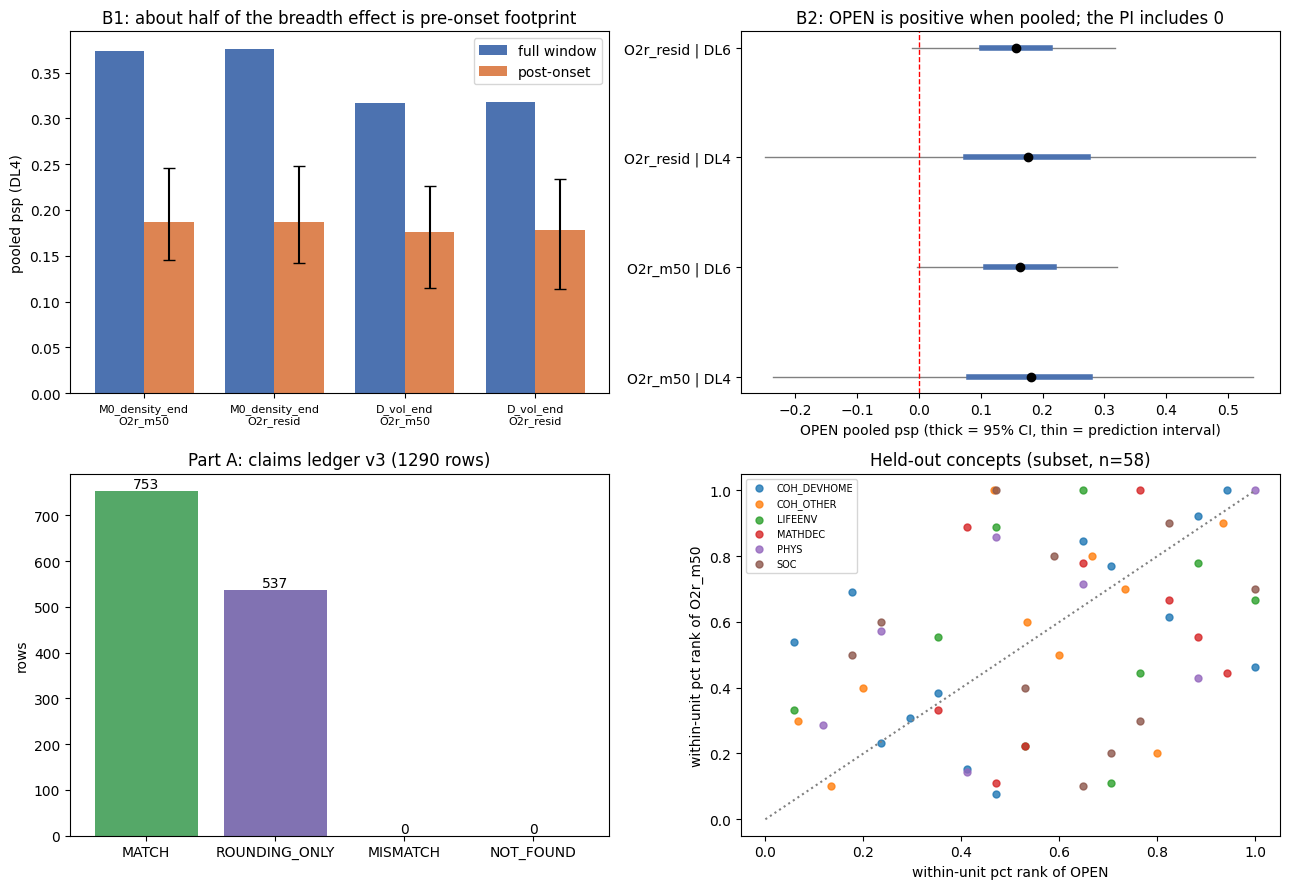

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1. B1 full vs post-onset psp (DL4)
labs, full, post, lo, hi = [], [], [], [], []
for tag, nm in (("M0", "M0_density_end"), ("Dvol", "D_vol_end")):
    for o in ("O2r_m50", "O2r_resid"):
        s = f"B1_{tag}_{o}"
        labs.append(f"{nm}\n{o}"); full.append(M[f"{s}_psp_full"]); post.append(M[f"{s}_psp_post"])
        lo.append(M[f"{s}_psp_post_ci_lo"]); hi.append(M[f"{s}_psp_post_ci_hi"])
x = np.arange(len(labs)); w = 0.38
ax[0, 0].bar(x - w/2, full, w, label="full window", color="#4C72B0")
ax[0, 0].bar(x + w/2, post, w, label="post-onset", color="#DD8452",
             yerr=[np.array(post) - lo, np.array(hi) - post], capsize=4)
ax[0, 0].set_xticks(x, labs, fontsize=8); ax[0, 0].set_ylabel("pooled psp (DL4)")
ax[0, 0].set_title("B1: about half of the breadth effect is pre-onset footprint"); ax[0, 0].legend()

# 2. B2 OPEN pooled psp with CI and prediction interval
keys = [(o, p) for o in ("O2r_m50", "O2r_resid") for p in ("DL4", "DL6")]
for i, (o, p) in enumerate(keys):
    s = f"OPEN_{o}_{p}"
    ax[0, 1].plot([M.get(f"{s}_pi_lo", np.nan), M.get(f"{s}_pi_hi", np.nan)], [i, i], color="grey", lw=1)
    ax[0, 1].plot([M[f"{s}_ci_lo"], M[f"{s}_ci_hi"]], [i, i], color="#4C72B0", lw=4)
    ax[0, 1].plot(M[f"{s}_psp"], i, "o", color="black")
ax[0, 1].axvline(0, color="red", ls="--", lw=1)
ax[0, 1].set_yticks(range(len(keys)), [f"{o} | {p}" for o, p in keys])
ax[0, 1].set_xlabel("OPEN pooled psp (thick = 95% CI, thin = prediction interval)")
ax[0, 1].set_title("B2: OPEN is positive when pooled; the PI includes 0")

# 3. Ledger status counts
st = {k: M[f"ledger_{k}"] for k in ("MATCH", "ROUNDING_ONLY", "MISMATCH", "NOT_FOUND")}
ax[1, 0].bar(list(st), list(st.values()), color=["#55A868", "#8172B2", "#C44E52", "#937860"])
for i, v in enumerate(st.values()):
    ax[1, 0].text(i, v, str(v), ha="center", va="bottom")
ax[1, 0].set_title(f"Part A: claims ledger v3 ({M['ledger_rows']} rows)"); ax[1, 0].set_ylabel("rows")

# 4. Concept-level rank agreement (subset)
C = pd.DataFrame(out["datasets"][0]["examples"])
C = C.dropna(subset=["eval_rank_pct_OPEN", "eval_rank_pct_O2r_m50"])
for u, g in C.groupby("metadata_unit"):
    ax[1, 1].scatter(g.eval_rank_pct_OPEN, g.eval_rank_pct_O2r_m50, label=u, s=25, alpha=0.8)
ax[1, 1].plot([0, 1], [0, 1], color="grey", ls=":")
ax[1, 1].set_xlabel("within-unit pct rank of OPEN"); ax[1, 1].set_ylabel("within-unit pct rank of O2r_m50")
ax[1, 1].set_title(f"Held-out concepts (subset, n={len(C)})"); ax[1, 1].legend(fontsize=7)
plt.tight_layout(); plt.show()